# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Camello, Zack Kenshin)_: 
- _Student No._: 2024-08825
- _Section_: THR-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

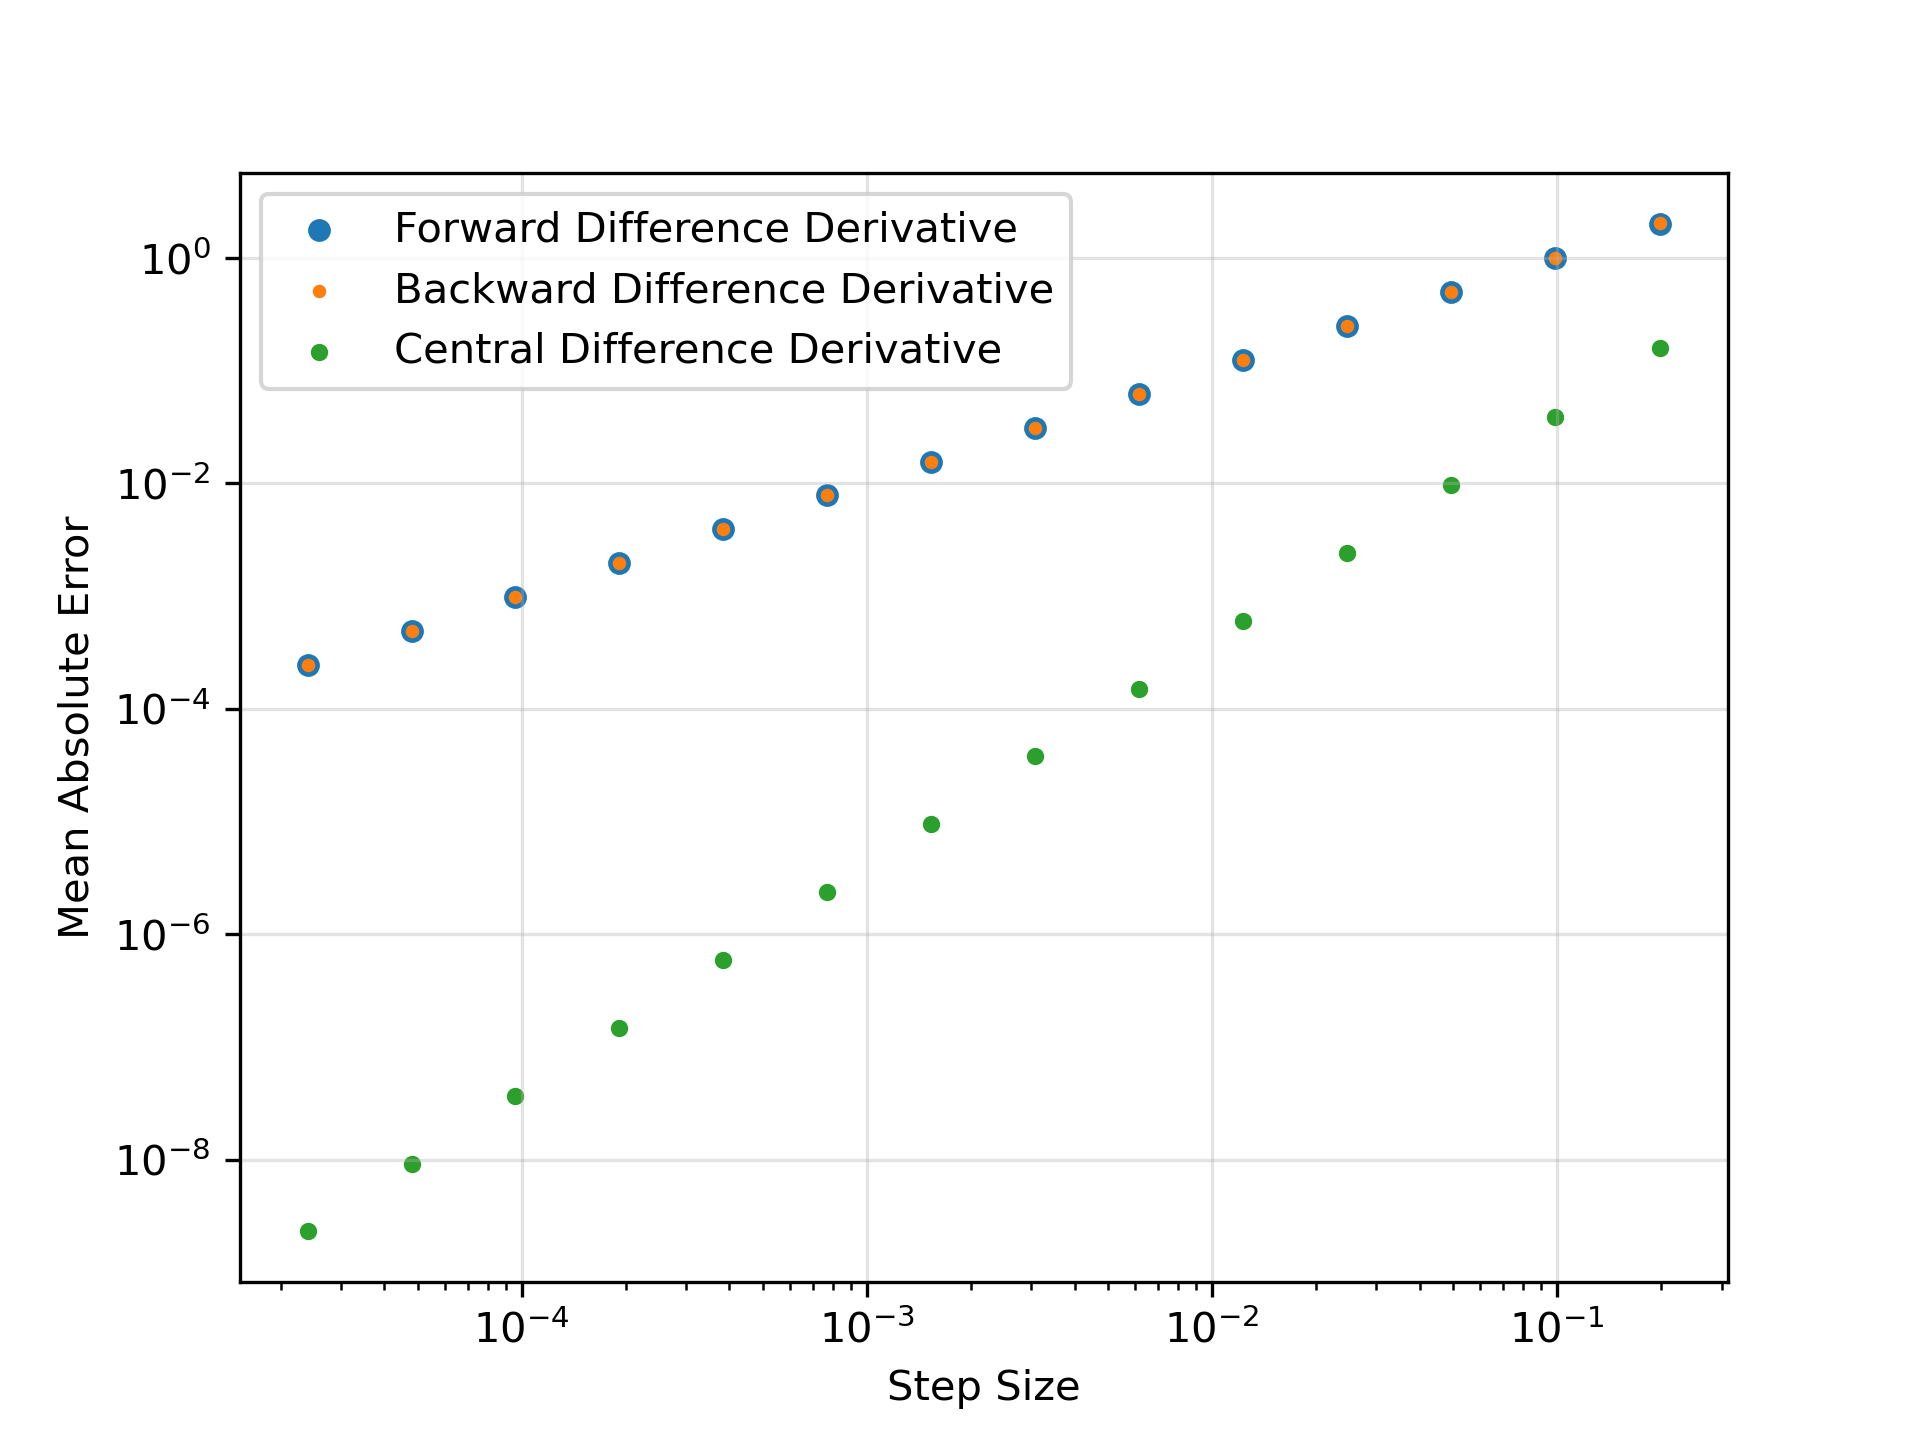


### Report discussion

Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 

As shown on the figure above, the Mean Absolute Error of the forward and backward formulas are nearly identical, while the central difference formula yields a significantly lower overall mean absolute error. The non-central difference formulas have higher inaccuracy mainly due to the fact that it is derived from the taylor expansion, with terms past the 2nd derivative ommited. On the other hand the central formula ommits values starting the 3rd derivative. Though this may not seem like much, the coefficient of the 2nd derivative is $\frac{h}{2}$, while the 3rd derivative is $\frac{h^2}{6}$. Because $\frac{h}{2} >>> \frac{h^2}{6}$, the error upon ommiting $\frac{h}{2}$ in the non-central formulas lead to an overall highg error in comparison to the central method. However, just because the central formula is more accurate, does not mean the non-central formulas are useless. For example, when observing data, you cannot look backwards beyond the very first data point, thus forcing us to use the forward difference formula. Similarly, you cannot look forwards beyond your very last data point, which forces the usage of backwards difference formula. 

### Other comments

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

Say you start with 257 points from 0 to $4\pi$ 

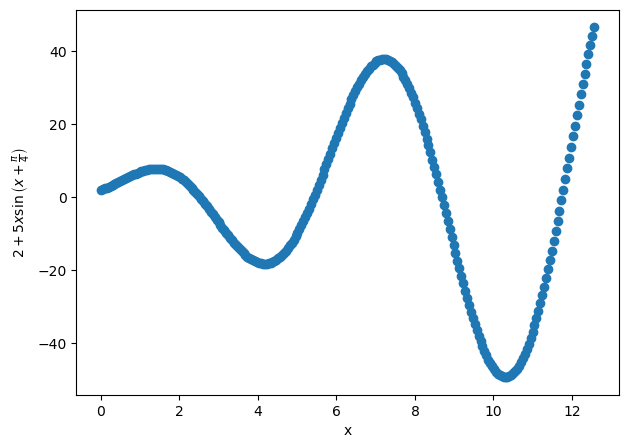

In [2]:
f_0 = lambda x: 2 + 5*x*np.sin(1*x+np.pi/4)
x = np.linspace(0, 4*np.pi, 257)
fig, ax = plt.subplots(figsize = (7,5))
ax.scatter(x, f_0(x))
ax.set_ylabel(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_xlabel("x")
fig.show()
fig.savefig('f_x.png')

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data
- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

- Get the mean absolute error of each of the approximations compared to the analytically derived function
- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

The derivative of the given function:
$$ f(x) = 2 + 5x\sin(x + \frac{\pi}{4})$$
$$f'(x) = 5sin(x + \frac{\pi}{4}) + 5xcos(x + \frac{\pi}{4})$$


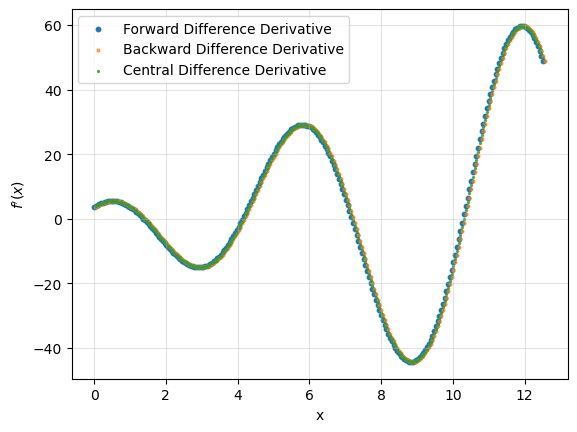

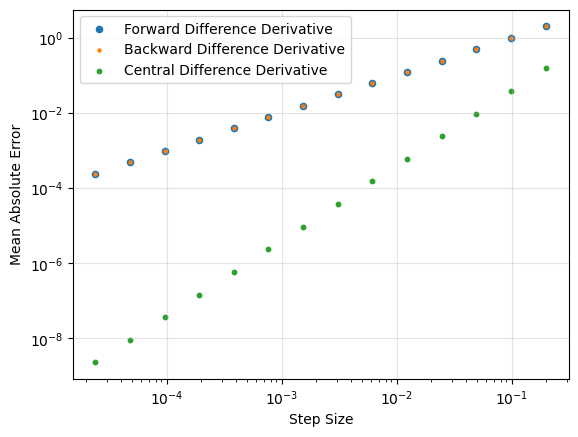

In [4]:
f_prime = lambda x: (5 * np.sin(x + (np.pi/4))) + (5 * x * np.cos(x + (np.pi/4)))

def manual_derivative(x, f_0):
    y = f_0(x) 
    h = x[1] - x[0]

    forward_x = x[:-1]
    forward_y = (y[1:] - y[0:-1])/h

    backward_x = x[1:]
    backward_y = (y[1:] - y[0:-1])/h

    central_x = x[1:-1]
    central_y = (y[2:] - y[0:-2])/(2*h)

    return forward_x, forward_y, backward_x, backward_y, central_x, central_y

def mae(spacing):
    error_forward = []
    error_backward = []
    error_central = []
    step_size = []
    while spacing < 1e6:
        x = np.linspace(0, 4*np.pi, spacing)
        forward_x, forward_y, backward_x, backward_y, central_x, central_y = manual_derivative(x, f_0)
        error_forward.append(np.mean(np.abs(forward_y - f_prime(forward_x))))
        error_backward.append(np.mean(np.abs(backward_y - f_prime(backward_x))))
        error_central.append(np.mean(np.abs(central_y - f_prime(central_x))))
        step_size.append(x[1] - x[0])
        spacing *= 2
    return error_forward, error_backward, error_central, step_size

forward_x, forward_y, backward_x, backward_y, central_x, central_y = manual_derivative(x, f_0)
error_forward, error_backward, error_central, step_size = mae(64)

plt.scatter(forward_x, forward_y, s = 10, label = "Forward Difference Derivative")
plt.scatter(backward_x, backward_y, s = 4, label = "Backward Difference Derivative", alpha = 0.65)
plt.scatter(central_x, central_y, s = 2, label = "Central Difference Derivative", alpha = 0.75)
plt.xlabel("x")
plt.ylabel(r"$f'(x)$")
plt.grid(True, alpha = 0.35)
plt.legend()
plt.savefig("Derivatives", dpi=300)
plt.show()

plt.xscale('log')
plt.yscale('log')
plt.scatter(step_size, error_forward, label = "Forward Difference Derivative", s = 20)
plt.scatter(step_size, error_backward, label = "Backward Difference Derivative", s = 5)
plt.scatter(step_size, error_central, label = "Central Difference Derivative", s = 10)
plt.xlabel("Step Size")
plt.ylabel("Mean Absolute Error")
plt.grid(True, alpha = 0.35)
plt.legend()
plt.savefig("Mean Absolute Error", dpi=300)
plt.show()

#### Problem 1 code summary

The algorithm above calculates, plots, and determines the mean absolute errors of the derivative of $f(x) = 2 + 5x\sin(x + \frac{\pi}{4})$ using the Forward, Backward, and Central Difference Derivative methods, alongside the exact Analyical Differentiation. For each method type, the mean absolute error is calculated at differing step sizes to visually demonstrate the mitigation of errors as the smaller step sizes.

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [5]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-8.  2.  2.  2.  2.  2.  2.  2.  2. -8.]
